In [342]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True
plt.style.use('seaborn-v0_8-colorblind')

In [345]:
results = pd.read_csv("wandb_results_PM2.csv")
df = results[results['State'] == 'finished']
df = df[
    ["model.name", "model.aggregation", "model.alpha_scalar"] + [col for col in df.columns if "final_scores" in col] 
] 
df.head()

,model.name,model.aggregation,model.alpha_scalar,final_scores/coherence/m0_to_m0,final_scores/coherence/m0_to_m0_cov,final_scores/coherence/m0_to_m1,final_scores/coherence/m0_to_m1_cov,final_scores/coherence/m0_to_m2,final_scores/coherence/m0_to_m2_cov,final_scores/coherence/m0_to_m3,...,final_scores/downstream_lr/aggregated/m1,final_scores/downstream_lr/aggregated/m2,final_scores/downstream_lr/aggregated/m3,final_scores/downstream_lr/aggregated/m4,final_scores/downstream_lr/unimodal/m0,final_scores/downstream_lr/unimodal/m1,final_scores/downstream_lr/unimodal/m2,final_scores/downstream_lr/unimodal/m3,final_scores/downstream_lr/unimodal/m4,final_scores/rec_loss
0,jointprior,avg,0.95,0.902244,0.902444,0.039062,0.922676,0.051883,0.922175,0.030248,...,0.967248,0.970553,0.948518,0.960637,0.975160,0.967248,0.970553,0.948518,0.960637,5440.217285
1,jointprior,avg,0.90,0.905549,0.905549,0.057492,0.895934,0.060096,0.913962,0.034455,...,0.964042,0.969952,0.942007,0.959535,0.971254,0.964042,0.969952,0.942007,0.959535,5443.416016
2,jointprior,avg,0.70,0.892127,0.892127,0.078926,0.850861,0.066907,0.883814,0.046875,...,0.955128,0.957632,0.914563,0.942308,0.966647,0.955128,0.957632,0.914563,0.942308,5444.133301
3,jointprior,avg,0.50,0.876502,0.876502,0.083233,0.724159,0.089243,0.751803,0.066006,...,0.937500,0.947416,0.878105,0.915164,0.952825,0.937500,0.947416,0.878105,0.915164,5451.012695
4,jointprior,avg,0.30,0.857572,0.857572,0.084335,0.461538,0.090144,0.480469,0.086639,...,0.922977,0.926282,0.858774,0.808994,0.920673,0.922977,0.926282,0.858774,0.808994,5449.703613


Update names.

In [346]:
old_name = df['model.name'] + df['model.aggregation']
new_name = old_name.str.replace("jointavg", "AVG", regex=False)
new_name = new_name.str.replace("jointprior", "JP", regex=False)
new_name = new_name.str.replace("joint", "", regex=False)
new_name = new_name.str.replace("avg", "", regex=False)
new_name = new_name.str.replace("moe", "MoE", regex=False)
new_name = new_name.str.replace("mopoe", "MoPoE", regex=False)
new_name = new_name.str.replace("mixedprior", "MMVM", regex=False)
new_name = new_name.str.replace("unimodal", "independent", regex=False)
df.loc[:, 'model.name'] = new_name
df.head()

,model.name,model.aggregation,model.alpha_scalar,final_scores/coherence/m0_to_m0,final_scores/coherence/m0_to_m0_cov,final_scores/coherence/m0_to_m1,final_scores/coherence/m0_to_m1_cov,final_scores/coherence/m0_to_m2,final_scores/coherence/m0_to_m2_cov,final_scores/coherence/m0_to_m3,...,final_scores/downstream_lr/aggregated/m1,final_scores/downstream_lr/aggregated/m2,final_scores/downstream_lr/aggregated/m3,final_scores/downstream_lr/aggregated/m4,final_scores/downstream_lr/unimodal/m0,final_scores/downstream_lr/unimodal/m1,final_scores/downstream_lr/unimodal/m2,final_scores/downstream_lr/unimodal/m3,final_scores/downstream_lr/unimodal/m4,final_scores/rec_loss
0,JP,avg,0.95,0.902244,0.902444,0.039062,0.922676,0.051883,0.922175,0.030248,...,0.967248,0.970553,0.948518,0.960637,0.975160,0.967248,0.970553,0.948518,0.960637,5440.217285
1,JP,avg,0.90,0.905549,0.905549,0.057492,0.895934,0.060096,0.913962,0.034455,...,0.964042,0.969952,0.942007,0.959535,0.971254,0.964042,0.969952,0.942007,0.959535,5443.416016
2,JP,avg,0.70,0.892127,0.892127,0.078926,0.850861,0.066907,0.883814,0.046875,...,0.955128,0.957632,0.914563,0.942308,0.966647,0.955128,0.957632,0.914563,0.942308,5444.133301
3,JP,avg,0.50,0.876502,0.876502,0.083233,0.724159,0.089243,0.751803,0.066006,...,0.937500,0.947416,0.878105,0.915164,0.952825,0.937500,0.947416,0.878105,0.915164,5451.012695
4,JP,avg,0.30,0.857572,0.857572,0.084335,0.461538,0.090144,0.480469,0.086639,...,0.922977,0.926282,0.858774,0.808994,0.920673,0.922977,0.926282,0.858774,0.808994,5449.703613


Generate new columns of averages.

In [347]:
views = ["m0", "m1", "m2", "m3", "m4"]
relationships = []
indiv_results = []
one_to_one = []
column_names = []
for view_a in views:
  view_a_list = []
  one_to_one.append(view_a + "_to_" + view_a)
  for view_b in views:
    relationships.append(view_a + "_to_" + view_b)
    if view_a != view_b:
      view_a_list.append(view_b + "_to_" + view_a)
  indiv_results.append(view_a_list) # store view_a list
  column_names.append(str(view_a))
  indiv_results.append([view + "_cov" for view in view_a_list])
  column_names.append(str(view_a) + "_cov")
    
indiv_results.append(one_to_one)
column_names.append("one_to_one")
indiv_results.append([rel + "_cov" for rel in one_to_one])
column_names.append("one_to_one_cov")

# calculate averages
for i, cols in enumerate(indiv_results): 
  df[column_names[i]] = df[["final_scores/coherence/" + rel for rel in cols]].mean(axis=1)

df.head()

,model.name,model.aggregation,model.alpha_scalar,final_scores/coherence/m0_to_m0,final_scores/coherence/m0_to_m0_cov,final_scores/coherence/m0_to_m1,final_scores/coherence/m0_to_m1_cov,final_scores/coherence/m0_to_m2,final_scores/coherence/m0_to_m2_cov,final_scores/coherence/m0_to_m3,...,m1,m1_cov,m2,m2_cov,m3,m3_cov,m4,m4_cov,one_to_one,one_to_one_cov
0,JP,avg,0.95,0.902244,0.902444,0.039062,0.922676,0.051883,0.922175,0.030248,...,0.095603,0.843274,0.089443,0.842273,0.089844,0.710963,0.091647,0.493465,0.941486,0.941466
1,JP,avg,0.90,0.905549,0.905549,0.057492,0.895934,0.060096,0.913962,0.034455,...,0.099609,0.808368,0.093324,0.827950,0.089093,0.767453,0.094376,0.477840,0.941767,0.941687
2,JP,avg,0.70,0.892127,0.892127,0.078926,0.850861,0.066907,0.883814,0.046875,...,0.098658,0.733048,0.095027,0.773438,0.089894,0.659255,0.096805,0.438151,0.937320,0.937340
3,JP,avg,0.50,0.876502,0.876502,0.083233,0.724159,0.089243,0.751803,0.066006,...,0.097531,0.650741,0.100836,0.671374,0.094025,0.565905,0.098207,0.328075,0.929848,0.929888
4,JP,avg,0.30,0.857572,0.857572,0.084335,0.461538,0.090144,0.480469,0.086639,...,0.096705,0.516802,0.097882,0.531626,0.095753,0.414113,0.100936,0.281576,0.924980,0.924980


Add a column indicating the rate at which the covariance based imputation approach gives better results than the standard approach. 

In [348]:
relationships_full = ["final_scores/coherence/" + rel for rel in relationships]
cov_better = []
for rel in relationships_full:
  cov_better.append((df[rel] < df[rel + "_cov"]))

df['cov_better'] = np.mean(np.array(cov_better), axis = 0)
df.head()

,model.name,model.aggregation,model.alpha_scalar,final_scores/coherence/m0_to_m0,final_scores/coherence/m0_to_m0_cov,final_scores/coherence/m0_to_m1,final_scores/coherence/m0_to_m1_cov,final_scores/coherence/m0_to_m2,final_scores/coherence/m0_to_m2_cov,final_scores/coherence/m0_to_m3,...,m1_cov,m2,m2_cov,m3,m3_cov,m4,m4_cov,one_to_one,one_to_one_cov,cov_better
0,JP,avg,0.95,0.902244,0.902444,0.039062,0.922676,0.051883,0.922175,0.030248,...,0.843274,0.089443,0.842273,0.089844,0.710963,0.091647,0.493465,0.941486,0.941466,0.84
1,JP,avg,0.90,0.905549,0.905549,0.057492,0.895934,0.060096,0.913962,0.034455,...,0.808368,0.093324,0.827950,0.089093,0.767453,0.094376,0.477840,0.941767,0.941687,0.80
2,JP,avg,0.70,0.892127,0.892127,0.078926,0.850861,0.066907,0.883814,0.046875,...,0.733048,0.095027,0.773438,0.089894,0.659255,0.096805,0.438151,0.937320,0.937340,0.84
3,JP,avg,0.50,0.876502,0.876502,0.083233,0.724159,0.089243,0.751803,0.066006,...,0.650741,0.100836,0.671374,0.094025,0.565905,0.098207,0.328075,0.929848,0.929888,0.88
4,JP,avg,0.30,0.857572,0.857572,0.084335,0.461538,0.090144,0.480469,0.086639,...,0.516802,0.097882,0.531626,0.095753,0.414113,0.100936,0.281576,0.924980,0.924980,0.84


Great a dataframe of the averages over results

In [349]:
metric_cols = [c for c in df.columns if "final_scores/coherence/m" in c]
metric_cols_cov = [c for c in metric_cols if "cov" in c]
metric_cols = [c for c in metric_cols if "cov" not in c]

In [402]:
df_subset = df.fillna(-1)
df_subset.loc[df_subset['model.name']== 'independent', 'model.alpha_scalar'] = 0
df_subset = df_subset[df_subset["model.alpha_scalar"] != -1]
df_subset['model.name'] = df_subset['model.name'] + ["-" + str(x) for x in df_subset['model.alpha_scalar']]
df_subset['model.name'] = [str(x) for x in df_subset['model.alpha_scalar']]
model_means_jp = df_subset.groupby("model.name")[metric_cols].mean()
model_means_jp_cov = df_subset.groupby("model.name")[metric_cols_cov].mean()
model_means_jp

,final_scores/coherence/m0_to_m0,final_scores/coherence/m0_to_m1,final_scores/coherence/m0_to_m2,final_scores/coherence/m0_to_m3,final_scores/coherence/m0_to_m4,final_scores/coherence/m1_to_m0,final_scores/coherence/m1_to_m1,final_scores/coherence/m1_to_m2,final_scores/coherence/m1_to_m3,final_scores/coherence/m1_to_m4,...,final_scores/coherence/m3_to_m0,final_scores/coherence/m3_to_m1,final_scores/coherence/m3_to_m2,final_scores/coherence/m3_to_m3,final_scores/coherence/m3_to_m4,final_scores/coherence/m4_to_m0,final_scores/coherence/m4_to_m1,final_scores/coherence/m4_to_m2,final_scores/coherence/m4_to_m3,final_scores/coherence/m4_to_m4
model.name,,,,,,,,,,,,,,,,,,,,,
0.0,0.808093,0.096695,0.097336,0.100541,0.101963,0.101703,0.963401,0.101322,0.101502,0.099038,...,0.101783,0.106691,0.101743,0.959595,0.102003,0.100240,0.100481,0.100220,0.098417,0.871194
0.1,0.825396,0.100761,0.101387,0.097556,0.097130,0.100786,0.965345,0.098708,0.096554,0.102314,...,0.101362,0.101362,0.102163,0.959059,0.099008,0.100811,0.099284,0.103516,0.099384,0.870893
0.3,0.858574,0.093174,0.094301,0.090395,0.094101,0.096129,0.965420,0.095778,0.096479,0.104016,...,0.100461,0.102865,0.098032,0.960136,0.099459,0.099509,0.100310,0.102289,0.098758,0.872571
0.5,0.879983,0.077799,0.080028,0.076472,0.081731,0.093525,0.966546,0.101963,0.097506,0.105193,...,0.096479,0.101212,0.098708,0.960387,0.098883,0.093550,0.104492,0.105669,0.098808,0.877980
0.7,0.894106,0.069686,0.065580,0.061123,0.077073,0.093900,0.968274,0.101512,0.100711,0.106320,...,0.094326,0.099609,0.095478,0.961814,0.098257,0.090144,0.107096,0.104192,0.098032,0.891526
0.9,0.907802,0.059420,0.056591,0.045999,0.057116,0.091972,0.969126,0.102364,0.101187,0.107998,...,0.088842,0.104467,0.095528,0.963942,0.105619,0.090445,0.114709,0.108849,0.104542,0.900341
0.93,0.907919,0.060530,0.057893,0.042835,0.061966,0.091346,0.970453,0.107238,0.098758,0.107806,...,0.088709,0.099559,0.100194,0.964610,0.102597,0.087340,0.117054,0.103065,0.104200,0.901242
0.95,0.908988,0.051883,0.050414,0.044171,0.062834,0.087240,0.969518,0.100628,0.102030,0.102397,...,0.085437,0.108707,0.107839,0.964543,0.111445,0.086906,0.113682,0.111779,0.114116,0.903045
0.97,0.912427,0.052417,0.055255,0.040532,0.060864,0.090678,0.970887,0.112780,0.098858,0.114383,...,0.087473,0.103866,0.113381,0.965478,0.108340,0.087974,0.122963,0.107973,0.109909,0.906851


In [403]:
model_means_jp_cov

,final_scores/coherence/m0_to_m0_cov,final_scores/coherence/m0_to_m1_cov,final_scores/coherence/m0_to_m2_cov,final_scores/coherence/m0_to_m3_cov,final_scores/coherence/m0_to_m4_cov,final_scores/coherence/m1_to_m0_cov,final_scores/coherence/m1_to_m1_cov,final_scores/coherence/m1_to_m2_cov,final_scores/coherence/m1_to_m3_cov,final_scores/coherence/m1_to_m4_cov,...,final_scores/coherence/m3_to_m0_cov,final_scores/coherence/m3_to_m1_cov,final_scores/coherence/m3_to_m2_cov,final_scores/coherence/m3_to_m3_cov,final_scores/coherence/m3_to_m4_cov,final_scores/coherence/m4_to_m0_cov,final_scores/coherence/m4_to_m1_cov,final_scores/coherence/m4_to_m2_cov,final_scores/coherence/m4_to_m3_cov,final_scores/coherence/m4_to_m4_cov
model.name,,,,,,,,,,,,,,,,,,,,,
0.0,0.808153,0.121975,0.119351,0.131951,0.113722,0.099119,0.963341,0.744812,0.597095,0.149499,...,0.101462,0.645994,0.653526,0.959635,0.151583,0.102424,0.171294,0.155869,0.181811,0.871094
0.1,0.825371,0.193485,0.172025,0.187099,0.121770,0.180889,0.965470,0.720778,0.572366,0.196464,...,0.172626,0.656375,0.631485,0.959160,0.195838,0.115610,0.178986,0.156100,0.163762,0.870918
0.3,0.858599,0.487380,0.474559,0.379332,0.185973,0.388421,0.965445,0.762445,0.556716,0.229041,...,0.362931,0.674930,0.665790,0.960086,0.230243,0.149464,0.226312,0.204102,0.187876,0.872571
0.5,0.879958,0.734049,0.737831,0.584660,0.310171,0.479467,0.966546,0.806741,0.613231,0.293269,...,0.440780,0.702374,0.698593,0.960362,0.285332,0.247872,0.378456,0.368990,0.326472,0.877980
0.7,0.893980,0.858799,0.873097,0.744015,0.417593,0.622997,0.968249,0.847631,0.687200,0.347982,...,0.555389,0.727339,0.730519,0.961839,0.329502,0.447992,0.566156,0.568234,0.492889,0.891526
0.9,0.907802,0.918620,0.922025,0.850711,0.595428,0.426783,0.969076,0.882687,0.758664,0.472907,...,0.396585,0.787109,0.790139,0.963967,0.428385,0.359650,0.719777,0.724334,0.638171,0.900190
0.93,0.907886,0.924679,0.934996,0.849392,0.683694,0.694945,0.970453,0.887487,0.750100,0.542435,...,0.633347,0.782853,0.797276,0.964643,0.496027,0.597356,0.727931,0.742889,0.634716,0.901175
0.95,0.909088,0.927250,0.929721,0.840678,0.627971,0.694645,0.969518,0.890124,0.722589,0.488114,...,0.638255,0.799947,0.800815,0.964510,0.461505,0.601062,0.751970,0.756444,0.622796,0.903045
0.97,0.912360,0.932192,0.933060,0.869525,0.612079,0.718316,0.970787,0.890825,0.756544,0.468383,...,0.664764,0.798678,0.800881,0.965445,0.432292,0.648504,0.755576,0.758180,0.660123,0.906851


## $\alpha$ tuning

### Functions


In [427]:

def extract_matrix(avg_series, cov=False):
    """Convert a row of averaged metrics into a square DataFrame."""
    tmp = avg_series.to_frame("value")
    if cov == False:
      ex = tmp.index.to_series().str.extract(r"m(\d+)_to_m(\d+)")
    else:
      ex = tmp.index.to_series().str.extract(r"m(\d+)_to_m(\d+)_cov")
    tmp["from"]   = "M" + ex[0].astype(str)
    tmp["to"] = "M" + ex[1].astype(str)
    tmp = tmp.dropna(subset=["to", "from"])
    return tmp.pivot(index="to", columns="from", values="value")

def produce_plots(matrices, filename, v_min=0, color_map='viridis', text_color='w', n_cols=0, n_rows=0, bottom=0):
  n_models = len(matrices)
  if n_cols == 0 :
    n_cols = min(3, n_models)  # up to 3 per row
    n_rows = int(np.ceil(n_models / n_cols))
  
  fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
  axes = np.array(axes).reshape(-1)  # flatten in case of 1 row
  # fig.delaxes(axes.flatten()[8])
  # fig.delaxes(axes.flatten()[11])
  for ax, (name, mat) in zip(axes, matrices.items()):
      if type(mat) == int:
        ax.axis("off")
        continue
      data = mat.values
      im = ax.imshow(data, cmap=color_map, vmin=v_min, vmax=1, interpolation='none')
      # ax.grid(None)
      ax.grid(visible=False)
      ax.set_title(f"{name}", fontsize=12)
      ax.set_xlabel("From")
      ax.set_ylabel("To")
      ax.set_xticks(np.arange(len(mat.columns)))
      ax.set_yticks(np.arange(len(mat.index)))
      ax.set_xticklabels(mat.columns)
      ax.set_yticklabels(mat.index)
      plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
      
      # Annotate cells
      for i in range(len(mat.index)):
          for j in range(len(mat.columns)):
              ax.text(j, i, f"{data[i, j]:.2f}", ha="center", va="center", color=text_color, fontsize=8)

  # Add a shared colorbar
  cbar = fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.05, pad=0.08, aspect=30)
  cbar.ax.set_position([0.3, bottom, 0.4, 0.03])  # [left, bottom, width, height]
  # cbar.ax.set_position([0.5, 0.2, 0.4, 0.03])  # [left, bottom, width, height]

  # Hide unused subplots (if any)
  for ax in axes[len(matrices):]:
      ax.axis("off")
      ax.grid(visible=False)
  
  plt.subplots_adjust(wspace=-0.2, hspace=0.35)
  # plt.tight_layout(rect=[0, 0.08, 1, 1])  
  # plt.tight_layout()
  plt.savefig(filename, bbox_inches='tight')
  plt.show()

In [490]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

def produce_plots(matrices, filename, v_min=0, color_map='viridis', text_color='w'):
    """
    Plot up to 10 heatmaps on a 3x4 grid, with the last two centered on the bottom row.
    Unused subplots are hidden.
    """
    n_models = len(matrices)
    n_total_slots = 12   # 3 rows x 4 columns
    n_rows, n_cols = 3, 4
    
    fig = plt.figure(figsize=(5*n_cols, 4*n_rows))
    gs = gridspec.GridSpec(n_rows, n_cols, figure=fig, wspace=-0.4, hspace=0.35)
    axes = []

    # Determine subplot positions
    # Top two rows: fill left to right (8 total)
    # Bottom row: center last two plots (columns 1 and 2)
    positions = [(r, c) for r in range(2) for c in range(n_cols)]  # first 8
    if n_models > 8:
        bottom_positions = [(2, 1), (2, 2)]  # centered bottom row
        positions.extend(bottom_positions[:n_models - 8])

    # Create subplots
    for (name, mat), pos in zip(matrices.items(), positions):
        ax = fig.add_subplot(gs[pos])
        data = mat.values
        im = ax.imshow(data, cmap=color_map, vmin=v_min, vmax=1, interpolation='none')
        ax.set_title(f"{name}", fontsize=12)
        ax.set_xlabel("From")
        ax.set_ylabel("To")
        ax.set_xticks(np.arange(len(mat.columns)))
        ax.set_yticks(np.arange(len(mat.index)))
        ax.set_xticklabels(mat.columns)
        ax.set_yticklabels(mat.index)
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
        ax.grid(False)

        # Annotate each cell
        for i in range(len(mat.index)):
            for j in range(len(mat.columns)):
                ax.text(j, i, f"{data[i, j]:.2f}", ha="center", va="center", color=text_color, fontsize=8)

        axes.append(ax)

    # Hide any unused subplot positions
    used_positions = positions
    all_positions = [(r, c) for r in range(n_rows) for c in range(n_cols)]
    for pos in all_positions:
        if pos not in used_positions:
            ax = fig.add_subplot(gs[pos])
            ax.axis("off")

    # Shared colorbar (horizontal)
    cbar = fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.05, pad=0.08, aspect=30)
    cbar.set_label("Average Value", fontsize=12)
    cbar.ax.set_position([0.3, 0.01, 0.4, 0.03])
    
    plt.subplots_adjust(wspace=-0.2, hspace=0.35)
    plt.margins(x=-0.3, y=-0.3)
    # plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig(filename, bbox_inches='tight')
    plt.show()


### Plots

In [417]:
matrices_jp = {name: extract_matrix(row) for name, row in model_means_jp.iterrows()}
matrices_jp_cov = {name: extract_matrix(row, True) for name, row in model_means_jp_cov.iterrows()}

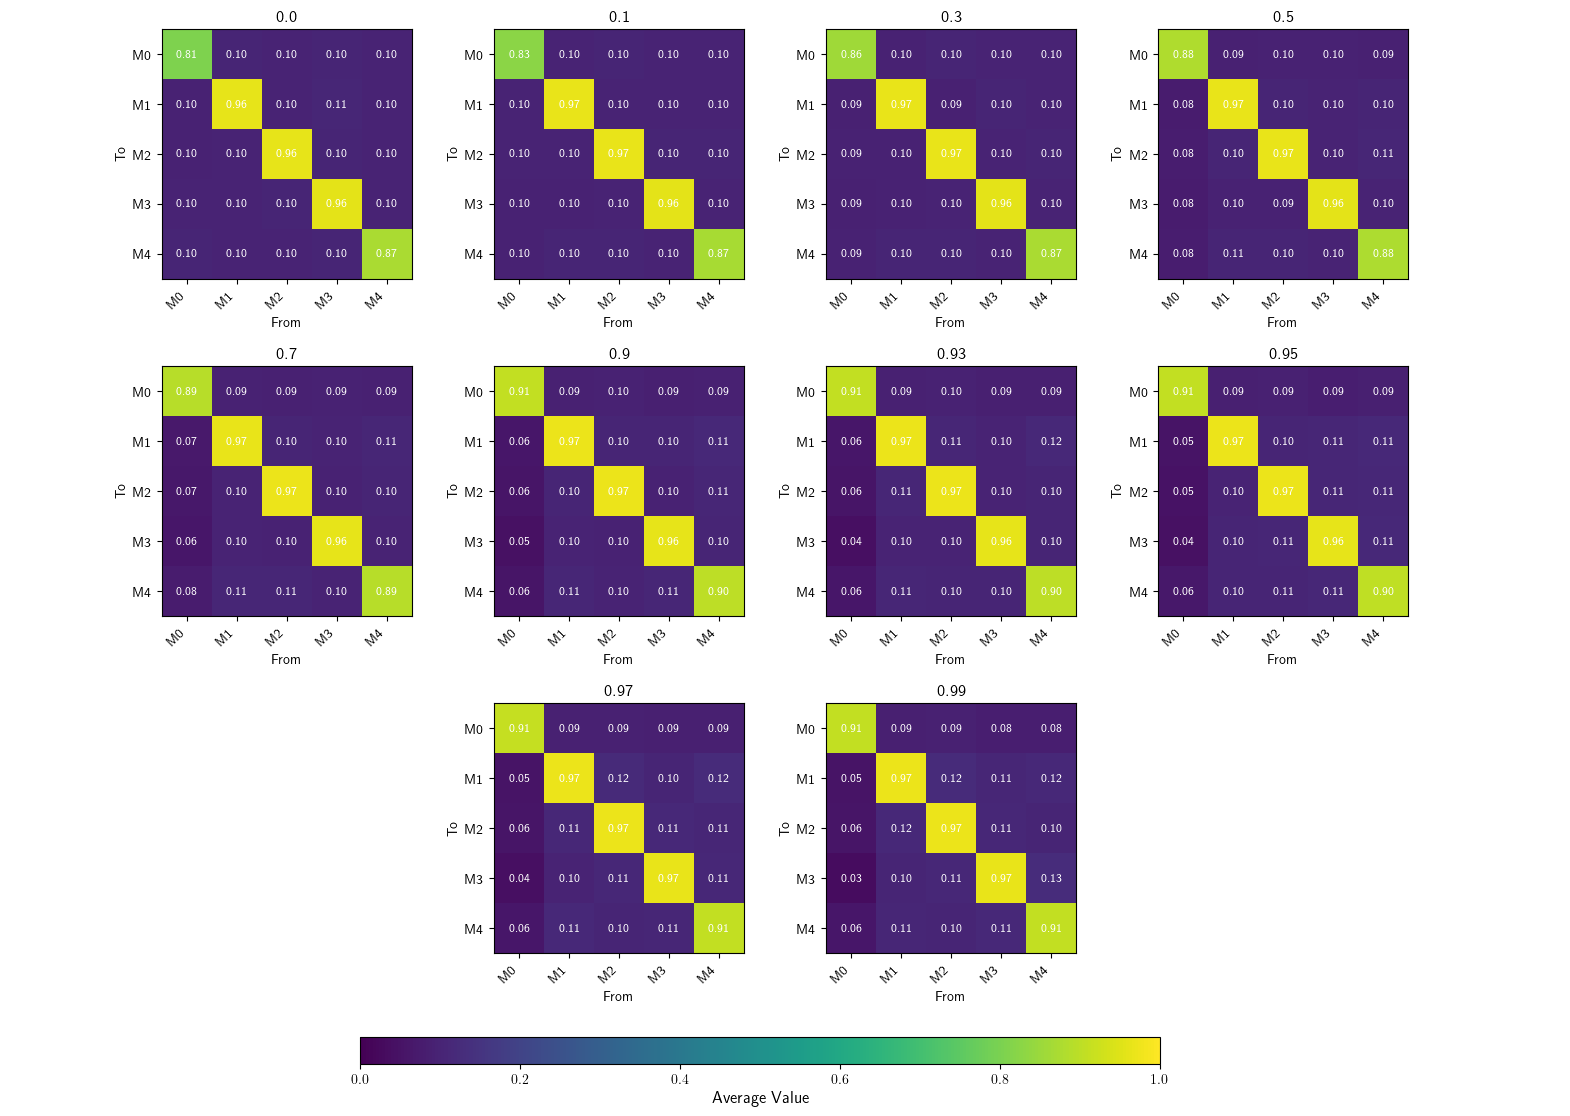

In [491]:
produce_plots(matrices_jp, "results_figures/alpha_heatmaps.png")

In [428]:
matrices_jp_cov['0.96'] = 0
matrices_jp_cov['1'] = 0

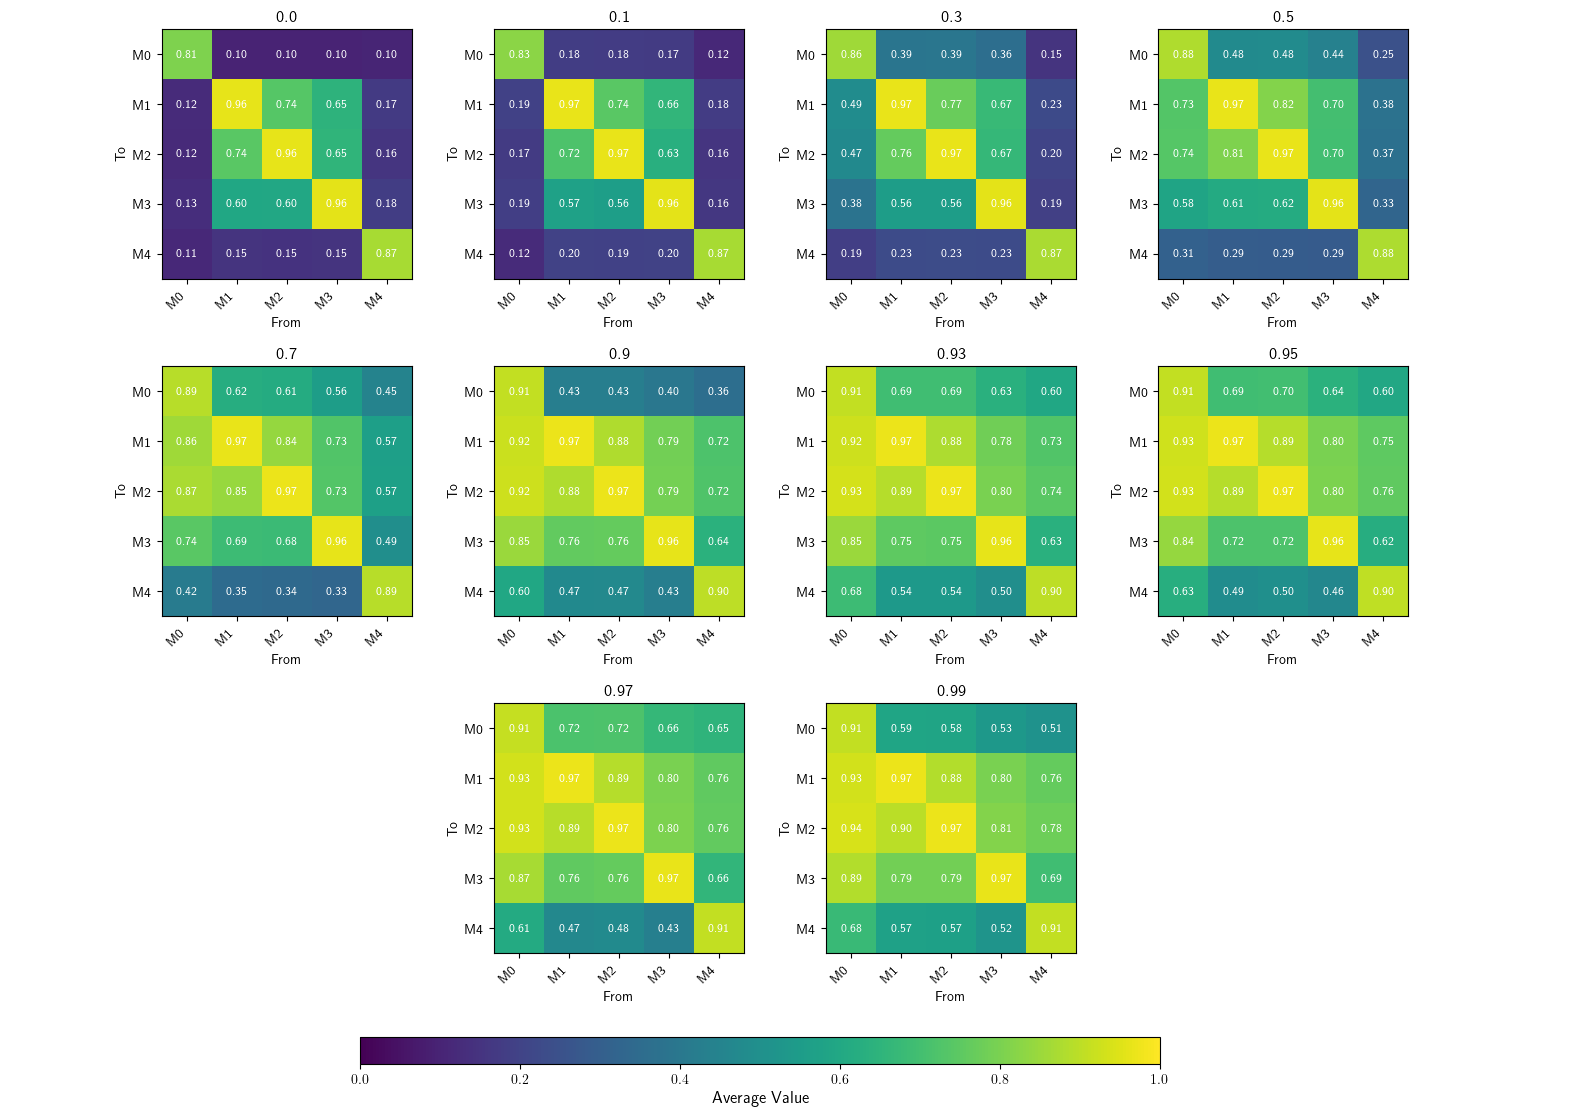

In [483]:
produce_plots(matrices_jp_cov, "results_figures/alpha_heatmaps_cov.png")

In [356]:
for i, view in enumerate(views):
  cols = ["final_scores/coherence/" + col for col in indiv_results[2 * i + 1]]
  average_name = view + "_average"
  best_name = view + "_best"
  model_means_jp_cov[average_name] = model_means_jp_cov[cols].mean(axis=1)
  model_means_jp_cov[best_name] = model_means_jp_cov[cols].max(axis=1)

model_means_jp_cov['average_overall'] = model_means_jp_cov[[view + "_average" for view in views]].mean(axis=1)
model_means_jp_cov['best_overall'] = model_means_jp_cov[[view + "_best" for view in views]].mean(axis=1)
model_means_jp_cov['average_coherence'] = model_means_jp_cov[["final_scores/coherence/" + view + "_to_" + view + "_cov" for view in views]].mean(axis=1)

In [357]:
cols = ([view + "_average" for view in views])
cols.append('average_overall')
alpha_averages = model_means_jp_cov[cols]
# best
cols = ([view + "_best" for view in views])
cols.append('best_overall')
alpha_best = model_means_jp_cov[cols]
# view-to-view
cols = (["final_scores/coherence/" + view + "_to_" + view + "_cov" for view in views])
cols.append('average_coherence')
view_to_view_averages = model_means_jp_cov[cols]


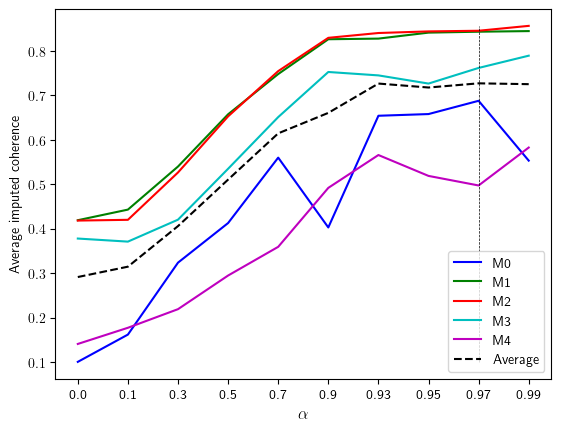

In [358]:
plt.style.use('seaborn-v0_8-colorblind')
legend_names = ["M" + str(i) for i in range(5)]
legend_names.append('Average')
# viridis = mpl.colormaps['viridis'].resampled(6)
cycler = plt.cycler(linestyle=['-', '-', '-', '-', '-', '--'], color='bgrcmk')
fig, ax = plt.subplots()
ax.set_prop_cycle(cycler)
ax.plot(alpha_averages)
ax.set_xlabel(r'$\alpha$', fontsize = 12)
ax.set_ylabel(r'Average imputed coherence')
ax.legend(legend_names, loc='lower right')
ax.vlines(
  np.argmax(model_means_jp_cov['average_overall']),
  np.min(alpha_averages), np.max(alpha_averages), 
  linestyles='dashed', 
  linewidth=0.5,
  colors='k')
plt.savefig('results_figures/average_impute_coherence.png')
plt.show()

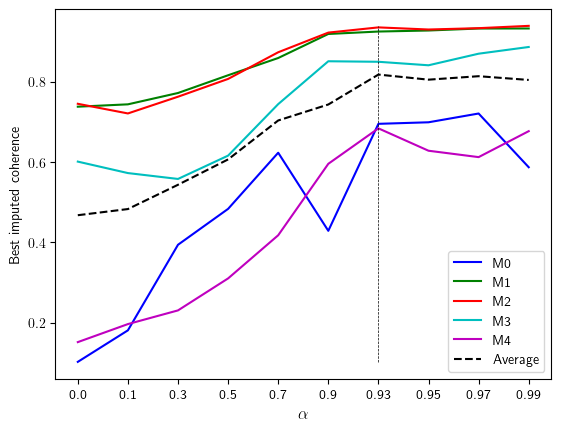

In [359]:
fig, ax = plt.subplots()
ax.set_prop_cycle(cycler)
ax.plot(alpha_best)
ax.set_xlabel(r'$\alpha$', fontsize = 12)
ax.set_ylabel(r'Best imputed coherence')
ax.legend(legend_names, loc='lower right')
ax.vlines(
  np.argmax(model_means_jp_cov['best_overall']),
  np.min(alpha_best), np.max(alpha_best), 
  linestyles='dashed', 
  linewidth=0.5,
  colors='k')
plt.savefig('results_figures/best_impute_coherence.png')
plt.show()

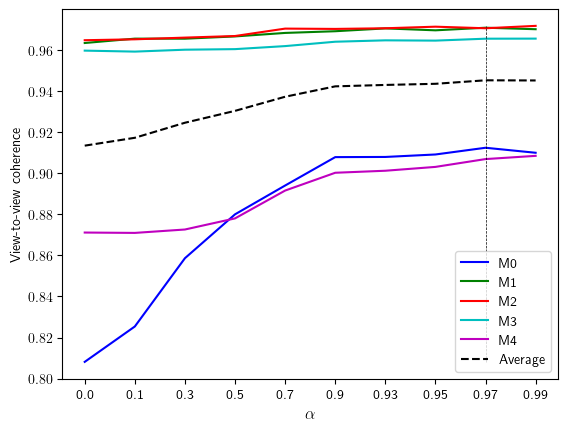

In [266]:
fig, ax = plt.subplots()
ax.set_prop_cycle(cycler)
ax.plot(view_to_view_averages)
ax.set_xlabel(r'$\alpha$', fontsize = 12)
ax.set_ylabel(r'View-to-view coherence')
ax.legend(legend_names, loc='lower right')
ax.vlines(
  np.argmax(model_means_jp_cov['average_coherence']),
  np.min(view_to_view_averages), np.max(view_to_view_averages), 
  linestyles='dashed', 
  linewidth=0.5,
  colors='k')
plt.savefig('results_figures/view_to_view_coherence.png')
plt.show()

We now compare different orderings of modalities.

In [360]:
labels=['independent', 'AVG', 'MoE', 'MoPoE','MMVM','JP']
results_mod = pd.read_csv("wandb_mod_order.csv")
results_mod = results_mod[
    ["model.name", "model.aggregation", "model.alpha_scalar", "dataset.modalities_order"] + [col for col in df.columns if "final_scores" in col] 
] 
results_mod["dataset.modalities_order"] = [int(res[1]) if res else 0 for res in results_mod[
  "dataset.modalities_order"
  ].fillna(0)]
results_mod.head()

,model.name,model.aggregation,model.alpha_scalar,dataset.modalities_order,final_scores/coherence/m0_to_m0,final_scores/coherence/m0_to_m0_cov,final_scores/coherence/m0_to_m1,final_scores/coherence/m0_to_m1_cov,final_scores/coherence/m0_to_m2,final_scores/coherence/m0_to_m2_cov,...,final_scores/downstream_lr/aggregated/m1,final_scores/downstream_lr/aggregated/m2,final_scores/downstream_lr/aggregated/m3,final_scores/downstream_lr/aggregated/m4,final_scores/downstream_lr/unimodal/m0,final_scores/downstream_lr/unimodal/m1,final_scores/downstream_lr/unimodal/m2,final_scores/downstream_lr/unimodal/m3,final_scores/downstream_lr/unimodal/m4,final_scores/rec_loss
0,jointprior,avg,0.9,0,0.905549,0.905549,0.057492,0.895934,0.060096,0.913962,...,0.964042,0.969952,0.942007,0.959535,0.971254,0.964042,0.969952,0.942007,0.959535,5443.416016
1,jointprior,avg,0.9,0,0.910757,0.910657,0.053786,0.924179,0.063001,0.920773,...,0.964543,0.968349,0.941106,0.960938,0.972756,0.964543,0.968349,0.941106,0.960938,5441.273926
2,jointprior,avg,0.9,3,0.873498,0.873498,0.100461,0.665365,0.103866,0.664864,...,0.965845,0.967348,0.981370,0.956230,0.942208,0.965845,0.967348,0.981370,0.956230,5439.176758
3,jointprior,avg,0.9,0,0.906951,0.906951,0.066907,0.927083,0.045373,0.930188,...,0.961639,0.967849,0.941406,0.960938,0.974259,0.961639,0.967849,0.941406,0.960938,5447.218262
4,jointprior,avg,0.9,0,0.907953,0.908053,0.059495,0.927284,0.057893,0.923177,...,0.963842,0.966847,0.942208,0.960036,0.974159,0.963842,0.966847,0.942208,0.960036,5444.120117


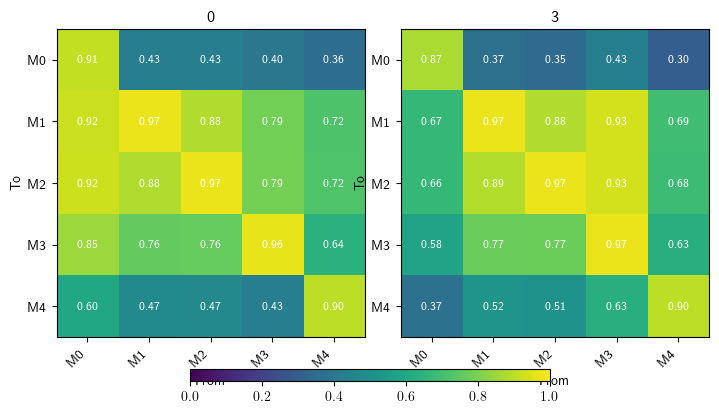

In [361]:
model_means_jp_mod = results_mod.groupby("dataset.modalities_order")[metric_cols_cov].mean()
matrices_jp_mod = {name: extract_matrix(row, True) for name, row in model_means_jp_mod.iterrows()}
produce_plots(matrices_jp_mod, "results_figures/alpha_heatmaps_mod.png", n_cols = 2, n_rows = 1)

## Heatmaps

In [ ]:
# --- Compute averages over repeats for each model ---
df['model.name'] = pd.Categorical(df['model.name'], labels, ordered=True)
df["model.alpha_scalar"] = df["model.alpha_scalar"].fillna(0)
df_subset = df.copy()
df_subset = df_subset[np.logical_or(
  df_subset["model.alpha_scalar"] == 0.97,
  df_subset["model.alpha_scalar"] == 0
  )]
model_means = df_subset.groupby("model.name", observed=True)[metric_cols].mean()
model_means

,final_scores/coherence/m0_to_m0,final_scores/coherence/m0_to_m1,final_scores/coherence/m0_to_m2,final_scores/coherence/m0_to_m3,final_scores/coherence/m0_to_m4,final_scores/coherence/m1_to_m0,final_scores/coherence/m1_to_m1,final_scores/coherence/m1_to_m2,final_scores/coherence/m1_to_m3,final_scores/coherence/m1_to_m4,...,final_scores/coherence/m3_to_m0,final_scores/coherence/m3_to_m1,final_scores/coherence/m3_to_m2,final_scores/coherence/m3_to_m3,final_scores/coherence/m3_to_m4,final_scores/coherence/m4_to_m0,final_scores/coherence/m4_to_m1,final_scores/coherence/m4_to_m2,final_scores/coherence/m4_to_m3,final_scores/coherence/m4_to_m4
model.name,,,,,,,,,,,,,,,,,,,,,
independent,0.808093,0.096695,0.097336,0.100541,0.101963,0.101703,0.963401,0.101322,0.101502,0.099038,...,0.101783,0.106691,0.101743,0.959595,0.102003,0.100240,0.100481,0.100220,0.098417,0.871194
AVG,0.550000,0.344050,0.353886,0.274519,0.341967,0.685577,0.771554,0.770713,0.520413,0.767989,...,0.655268,0.655429,0.683794,0.842668,0.756691,0.318690,0.351342,0.348157,0.258814,0.440865
MoE,0.780849,0.867728,0.874900,0.852204,0.828165,0.846254,0.899139,0.907171,0.886799,0.858173,...,0.815805,0.864083,0.874239,0.868009,0.814083,0.828566,0.880409,0.888622,0.866567,0.851062
MoPoE,0.700761,0.691086,0.709155,0.684335,0.629547,0.736679,0.860337,0.823077,0.790585,0.719231,...,0.684896,0.745032,0.763401,0.846655,0.650681,0.653966,0.704147,0.720713,0.691887,0.731931
MMVM,0.850200,0.846254,0.853466,0.839383,0.829447,0.809455,0.944311,0.898838,0.879407,0.869010,...,0.795312,0.877123,0.882492,0.944471,0.857432,0.773197,0.855509,0.858954,0.842468,0.885216
JP,0.912427,0.052417,0.055255,0.040532,0.060864,0.090678,0.970887,0.112780,0.098858,0.114383,...,0.087473,0.103866,0.113381,0.965478,0.108340,0.087974,0.122963,0.107973,0.109909,0.906851


In [268]:
model_means_cov = df_subset.groupby("model.name", observed=True)[metric_cols_cov].mean()
model_means_cov

,final_scores/coherence/m0_to_m0_cov,final_scores/coherence/m0_to_m1_cov,final_scores/coherence/m0_to_m2_cov,final_scores/coherence/m0_to_m3_cov,final_scores/coherence/m0_to_m4_cov,final_scores/coherence/m1_to_m0_cov,final_scores/coherence/m1_to_m1_cov,final_scores/coherence/m1_to_m2_cov,final_scores/coherence/m1_to_m3_cov,final_scores/coherence/m1_to_m4_cov,...,final_scores/coherence/m3_to_m0_cov,final_scores/coherence/m3_to_m1_cov,final_scores/coherence/m3_to_m2_cov,final_scores/coherence/m3_to_m3_cov,final_scores/coherence/m3_to_m4_cov,final_scores/coherence/m4_to_m0_cov,final_scores/coherence/m4_to_m1_cov,final_scores/coherence/m4_to_m2_cov,final_scores/coherence/m4_to_m3_cov,final_scores/coherence/m4_to_m4_cov
model.name,,,,,,,,,,,,,,,,,,,,,
independent,0.808153,0.121975,0.119351,0.131951,0.113722,0.099119,0.963341,0.744812,0.597095,0.149499,...,0.101462,0.645994,0.653526,0.959635,0.151583,0.102424,0.171294,0.155869,0.181811,0.871094
AVG,0.536659,0.512179,0.504107,0.493870,0.427524,0.311558,0.767748,0.738582,0.784655,0.682011,...,0.289083,0.708133,0.695994,0.841166,0.635637,0.271514,0.629547,0.620553,0.635877,0.440645
MoE,0.780849,0.801382,0.808954,0.604107,0.767588,0.758474,0.899159,0.828005,0.609896,0.779367,...,0.729307,0.796454,0.800681,0.868129,0.749139,0.752985,0.810096,0.818770,0.610256,0.851122
MoPoE,0.700801,0.618049,0.646254,0.504808,0.571995,0.598217,0.860417,0.772095,0.595673,0.675601,...,0.580909,0.707332,0.728506,0.846655,0.637881,0.530629,0.638742,0.656971,0.514002,0.731931
MMVM,0.850160,0.786038,0.788622,0.696494,0.535998,0.362220,0.944231,0.831090,0.727684,0.556210,...,0.373458,0.822696,0.822456,0.944491,0.565365,0.360757,0.787780,0.789603,0.694111,0.885296
JP,0.912360,0.932192,0.933060,0.869525,0.612079,0.718316,0.970787,0.890825,0.756544,0.468383,...,0.664764,0.798678,0.800881,0.965445,0.432292,0.648504,0.755576,0.758180,0.660123,0.906851


In [269]:
matrices = {name: extract_matrix(row) for name, row in model_means.iterrows()}
matrices_cov = {name: extract_matrix(row, True) for name, row in model_means_cov.iterrows()}

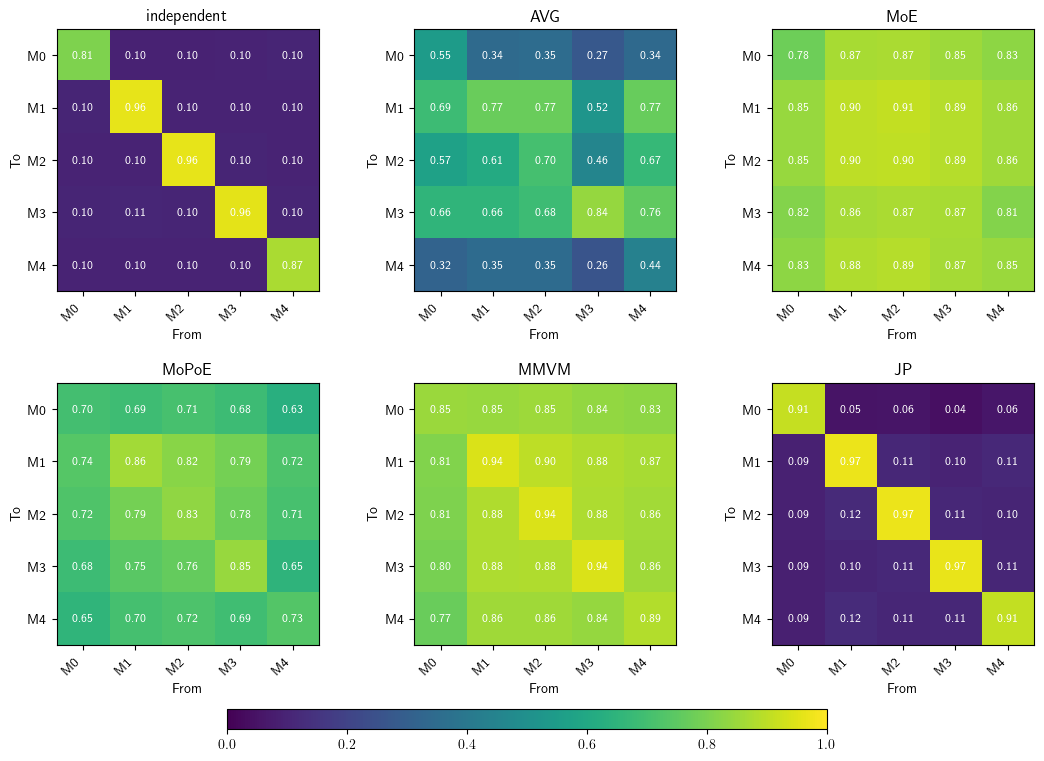

In [270]:
produce_plots(matrices,  "results_figures/methods_heatmaps.png")

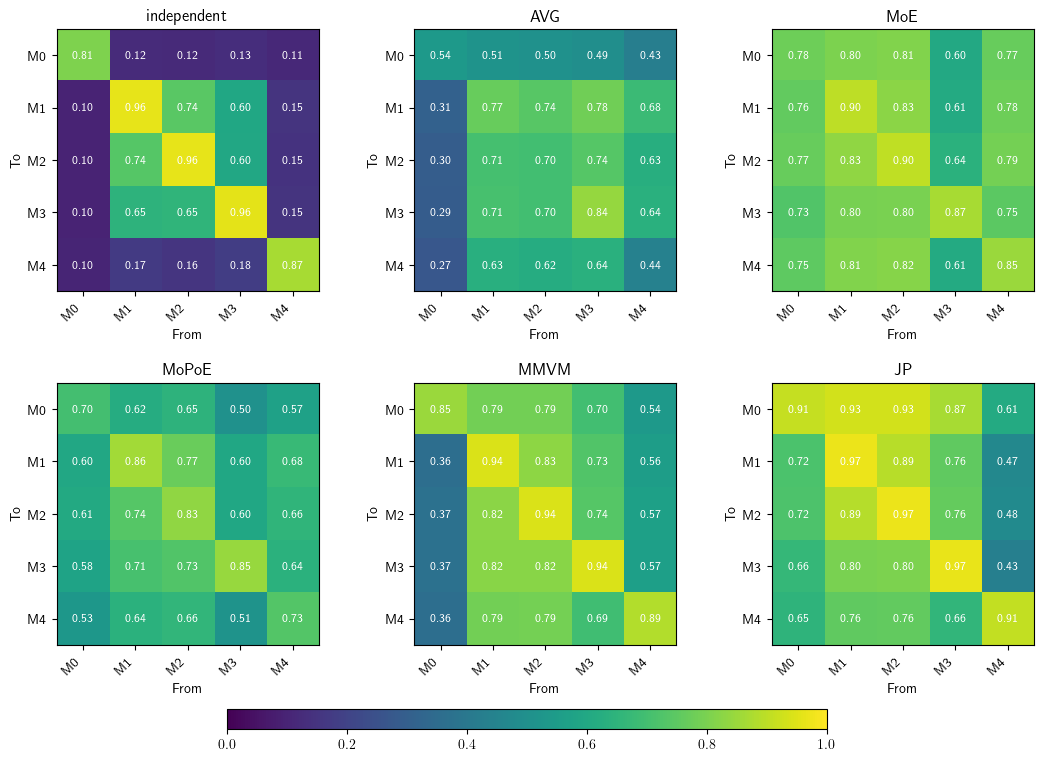

In [271]:
produce_plots(matrices_cov,  "results_figures/methods_heatmaps_cov.png")

In [272]:
matrix_diff = {}
for key in matrices_cov.keys():
  matrix_diff[key] = matrices_cov[key] - matrices[key] 

Investigating the impact of different values of $\alpha$ on the performance of JPVAE.

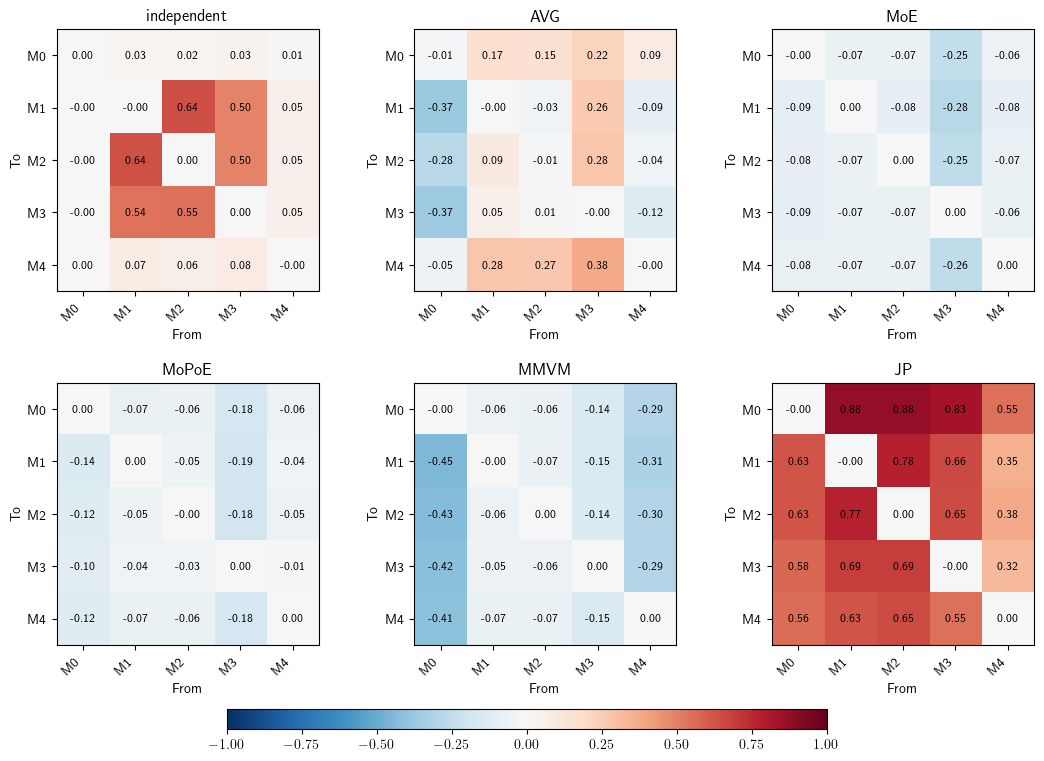

In [273]:
produce_plots(matrix_diff,  "results_figures/methods_heatmaps_diff.png",v_min =-1, color_map='RdBu_r', text_color='k')

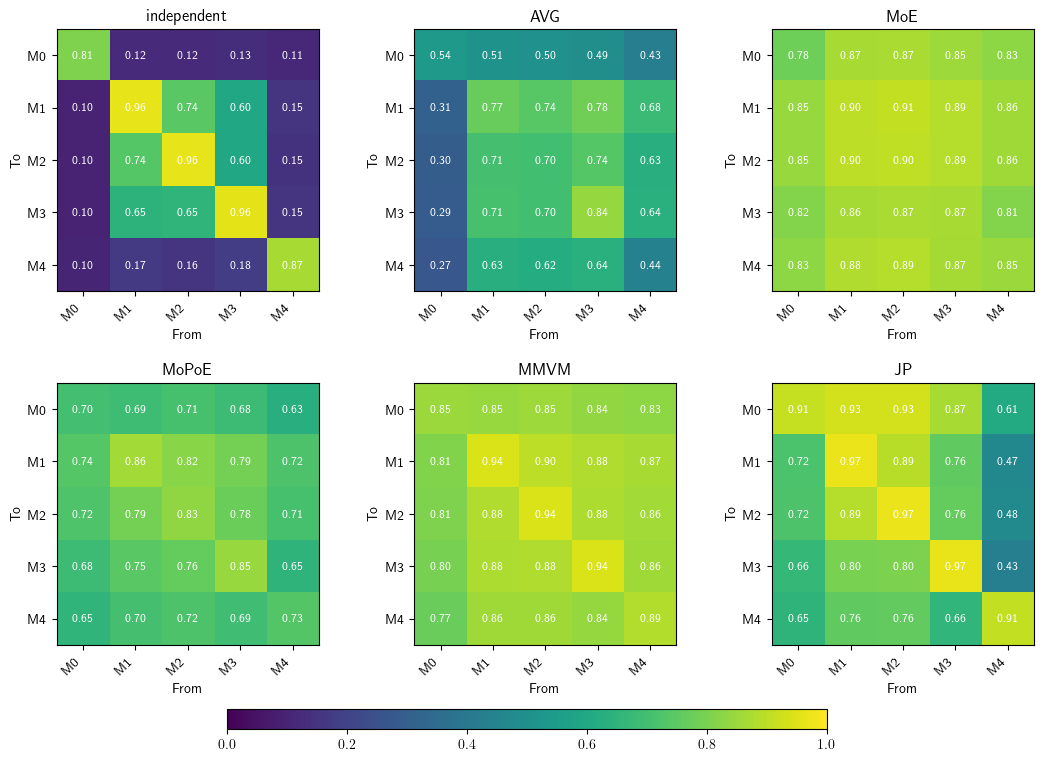

In [274]:
best_results = {
                'independent':matrices_cov['independent'], 
                'AVG':matrices_cov['AVG'],
                'MoE':matrices['MoE'],
                'MoPoE':matrices['MoPoE'],
                'MMVM':matrices['MMVM'],
                'JP':matrices_cov['JP']
                }
produce_plots(best_results,  "results_figures/methods_heatmaps_best.png")

In [325]:
(93+93+86+61)/4, (72+72+66+65)/4

(83.25, 68.75)

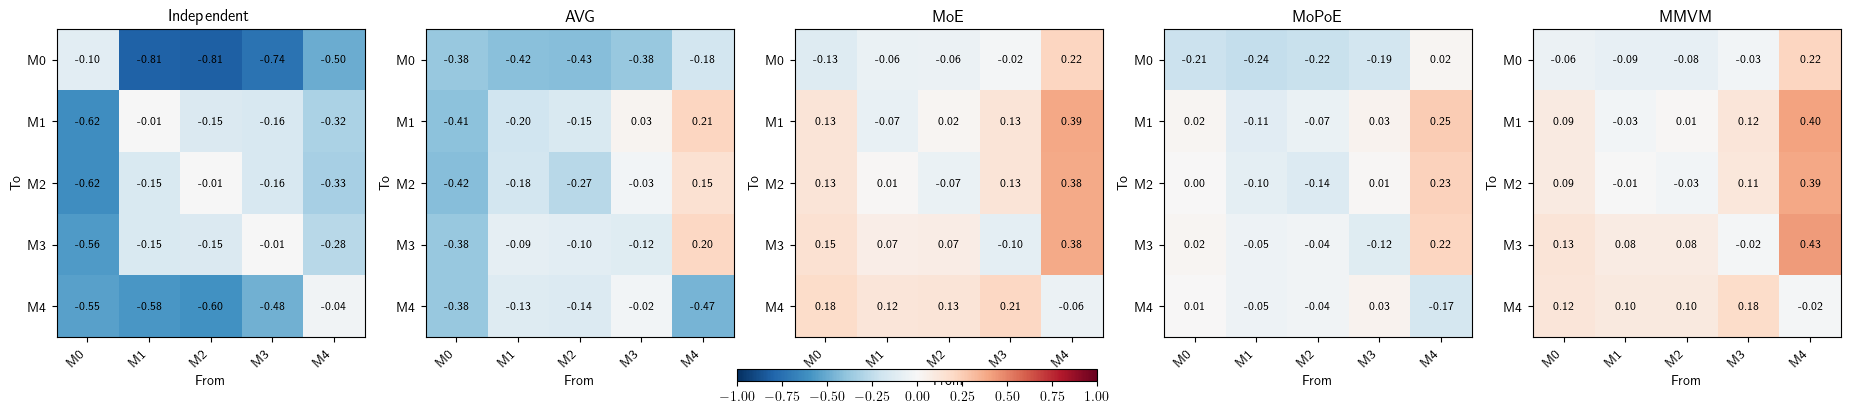

In [275]:
best_results = {'Independent':matrices_cov['independent']-matrices_cov['JP'],
                'AVG':matrices_cov['AVG']-matrices_cov['JP'],
                'MoE':matrices['MoE']-matrices_cov['JP'],
                'MoPoE':matrices['MoPoE']-matrices_cov['JP'],
                'MMVM':matrices['MMVM']-matrices_cov['JP']
                }
produce_plots(best_results,  "results_figures/methods_heatmaps_best.png", v_min=-1, color_map='RdBu_r', text_color='k', n_cols=5, n_rows=1)

In [276]:
# df_subset = df.fillna(0)
df_subset = df.copy()
df_subset = df_subset[np.logical_or(
  df_subset["model.alpha_scalar"] == 0.97,
  df_subset["model.alpha_scalar"] == 0
  )]
df_subset

,model.name,model.aggregation,model.alpha_scalar,final_scores/coherence/m0_to_m0,final_scores/coherence/m0_to_m0_cov,final_scores/coherence/m0_to_m1,final_scores/coherence/m0_to_m1_cov,final_scores/coherence/m0_to_m2,final_scores/coherence/m0_to_m2_cov,final_scores/coherence/m0_to_m3,...,m1_cov,m2,m2_cov,m3,m3_cov,m4,m4_cov,one_to_one,one_to_one_cov,cov_better
7,JP,avg,0.97,0.908754,0.908754,0.048177,0.931390,0.044371,0.938101,0.038562,...,0.842072,0.103115,0.849684,0.085487,0.777269,0.098357,0.578676,0.944511,0.944491,0.84
15,JP,avg,0.97,0.905549,0.905349,0.061699,0.933794,0.063502,0.929788,0.054788,...,0.846004,0.093800,0.844076,0.096905,0.756085,0.093475,0.506836,0.943970,0.943950,0.84
24,JP,avg,0.97,0.922977,0.922977,0.047376,0.931390,0.057893,0.931290,0.028245,...,0.842698,0.095127,0.843450,0.088442,0.752729,0.097055,0.406726,0.947155,0.947135,0.84
32,independent,avg,0.00,0.813902,0.813902,0.101763,0.116386,0.098357,0.121094,0.098858,...,0.421274,0.100686,0.410181,0.099309,0.376678,0.101162,0.190154,0.914103,0.914063,0.68
33,independent,avg,0.00,0.803986,0.804087,0.097256,0.116687,0.098958,0.119692,0.100461,...,0.411934,0.099609,0.416842,0.099359,0.417443,0.101713,0.155799,0.912981,0.913001,0.80
34,independent,avg,0.00,0.805288,0.805288,0.093850,0.120994,0.097556,0.115585,0.103866,...,0.407953,0.095653,0.410031,0.101888,0.382762,0.101362,0.116061,0.912640,0.912700,0.72
35,independent,avg,0.00,0.804187,0.804287,0.093450,0.135016,0.097957,0.120393,0.098257,...,0.426357,0.101688,0.421374,0.101913,0.385792,0.098983,0.124649,0.912079,0.912039,0.84
36,independent,avg,0.00,0.813101,0.813201,0.097155,0.120793,0.093850,0.119992,0.101262,...,0.428561,0.103140,0.433519,0.100936,0.327023,0.098483,0.116511,0.915144,0.915124,0.88
37,MMVM,avg,0.00,0.852564,0.852564,0.841947,0.751202,0.848958,0.771234,0.836839,...,0.772812,0.867939,0.792568,0.852189,0.684120,0.845077,0.464944,0.911579,0.911579,0.04
38,MMVM,avg,0.00,0.846354,0.846354,0.846855,0.805188,0.848057,0.771735,0.835837,...,0.828951,0.878631,0.803135,0.859726,0.677634,0.860777,0.606270,0.913862,0.913922,0.08


In [277]:
model_map = {'AVG':1, "JP":1, "independent":1, "MMVM":0, "MoPoE":0, "MoE":0}
df_subset["covariance"] = df_subset["model.name"].map(model_map)


for view_a in views:
  var_name = view_a + "_to_" + view_a
  df_subset["coh/" + var_name] = np.where(df_subset["covariance"],
                                   df_subset["final_scores/coherence/" + var_name + "_cov"],
                                   df_subset["final_scores/coherence/" + var_name])
  for view_b in views:
    var_name2 = view_a + "_to_" + view_b
    df_subset["coh/" + var_name2] = np.where(df_subset["covariance"],
                                   df_subset["final_scores/coherence/" + var_name2 + "_cov"],
                                   df_subset["final_scores/coherence/" + var_name2])
    
df_subset.head()

,model.name,model.aggregation,model.alpha_scalar,final_scores/coherence/m0_to_m0,final_scores/coherence/m0_to_m0_cov,final_scores/coherence/m0_to_m1,final_scores/coherence/m0_to_m1_cov,final_scores/coherence/m0_to_m2,final_scores/coherence/m0_to_m2_cov,final_scores/coherence/m0_to_m3,...,coh/m3_to_m3,coh/m3_to_m0,coh/m3_to_m1,coh/m3_to_m2,coh/m3_to_m4,coh/m4_to_m4,coh/m4_to_m0,coh/m4_to_m1,coh/m4_to_m2,coh/m4_to_m3
7,JP,avg,0.97,0.908754,0.908754,0.048177,0.931390,0.044371,0.938101,0.038562,...,0.964443,0.588842,0.789463,0.800280,0.499099,0.910857,0.579627,0.762620,0.766627,0.671174
15,JP,avg,0.97,0.905549,0.905349,0.061699,0.933794,0.063502,0.929788,0.054788,...,0.965946,0.678486,0.802684,0.803385,0.443309,0.906550,0.660557,0.752103,0.746094,0.652845
24,JP,avg,0.97,0.922977,0.922977,0.047376,0.931390,0.057893,0.931290,0.028245,...,0.965946,0.726963,0.803886,0.798978,0.354467,0.903145,0.705329,0.752003,0.761819,0.656350
32,independent,avg,0.00,0.813902,0.813902,0.101763,0.116386,0.098357,0.121094,0.098858,...,0.960337,0.078826,0.651943,0.642027,0.213842,0.870693,0.099559,0.173778,0.155950,0.190004
33,independent,avg,0.00,0.803986,0.804087,0.097256,0.116687,0.098958,0.119692,0.100461,...,0.958133,0.107973,0.630809,0.643229,0.174980,0.871695,0.097155,0.162861,0.153746,0.220152


In [278]:
for i, view in enumerate(views):
  cols = ["coh/" + col for col in indiv_results[2 * i]]
  average_name = view + "_average"
  best_name = view + "_best"
  df_subset[average_name] = df_subset[cols].mean(axis=1)
  df_subset[best_name] = df_subset[cols].max(axis=1)

df_subset['average_overall'] = df_subset[[view + "_average" for view in views]].mean(axis=1)
df_subset['best_overall'] = df_subset[[view + "_best" for view in views]].mean(axis=1)
df_subset['average_coherence'] = df_subset[["coh/" + view + "_to_" + view for view in views]].mean(axis=1)
df_subset.head()

,model.name,model.aggregation,model.alpha_scalar,final_scores/coherence/m0_to_m0,final_scores/coherence/m0_to_m0_cov,final_scores/coherence/m0_to_m1,final_scores/coherence/m0_to_m1_cov,final_scores/coherence/m0_to_m2,final_scores/coherence/m0_to_m2_cov,final_scores/coherence/m0_to_m3,...,m1_best,m2_average,m2_best,m3_average,m3_best,m4_average,m4_best,average_overall,best_overall,average_coherence
7,JP,avg,0.97,0.908754,0.908754,0.048177,0.931390,0.044371,0.938101,0.038562,...,0.931390,0.849684,0.938101,0.777269,0.891026,0.578676,0.714143,0.731125,0.822516,0.944491
15,JP,avg,0.97,0.905549,0.905349,0.061699,0.933794,0.063502,0.929788,0.054788,...,0.933794,0.844076,0.929788,0.756085,0.857472,0.506836,0.597356,0.732176,0.813001,0.943950
24,JP,avg,0.97,0.922977,0.922977,0.047376,0.931390,0.057893,0.931290,0.028245,...,0.931390,0.843450,0.931290,0.752729,0.860076,0.406726,0.524740,0.718790,0.806110,0.947135
32,independent,avg,0.00,0.813902,0.813902,0.101763,0.116386,0.098357,0.121094,0.098858,...,0.742989,0.410181,0.721655,0.376678,0.593149,0.190154,0.220453,0.296294,0.475561,0.914063
33,independent,avg,0.00,0.803986,0.804087,0.097256,0.116687,0.098958,0.119692,0.100461,...,0.737380,0.416842,0.750701,0.417443,0.658754,0.155799,0.174980,0.301057,0.485958,0.913001


In [333]:
df_subset[["model.name", "final_scores/coherence/m0_to_m4_cov"]]

,model.name,final_scores/coherence/m0_to_m4_cov
7,JP,0.714143
15,JP,0.597356
24,JP,0.524740
32,independent,0.114283
33,independent,0.113582
34,independent,0.113582
35,independent,0.113582
36,independent,0.113582
37,MMVM,0.448518
38,MMVM,0.585337


In [280]:
for i, view in enumerate(views):
  cols = ["coh/" + col for col in indiv_results[2 * i]]
  cols.append("final_scores/coherence/" + view + "_to_" + view)
  average_name = view + "_average_inc_view"
  df_subset[average_name] = df_subset[cols].mean(axis=1)

df_subset['average_overall_inc_view'] = df_subset[[view + "_average_inc_view" for view in views]].mean(axis=1)
df_subset.head()

,model.name,model.aggregation,model.alpha_scalar,final_scores/coherence/m0_to_m0,final_scores/coherence/m0_to_m0_cov,final_scores/coherence/m0_to_m1,final_scores/coherence/m0_to_m1_cov,final_scores/coherence/m0_to_m2,final_scores/coherence/m0_to_m2_cov,final_scores/coherence/m0_to_m3,...,m4_best,average_overall,best_overall,average_coherence,m0_average_inc_view,m1_average_inc_view,m2_average_inc_view,m3_average_inc_view,m4_average_inc_view,average_overall_inc_view
7,JP,avg,0.97,0.908754,0.908754,0.048177,0.931390,0.044371,0.938101,0.038562,...,0.714143,0.731125,0.822516,0.944491,0.668089,0.867728,0.873337,0.814724,0.645132,0.773802
15,JP,avg,0.97,0.905549,0.905349,0.061699,0.933794,0.063502,0.929788,0.054788,...,0.597356,0.732176,0.813001,0.943950,0.747416,0.870893,0.869551,0.798057,0.586759,0.774535
24,JP,avg,0.97,0.922977,0.922977,0.047376,0.931390,0.057893,0.931290,0.028245,...,0.524740,0.718790,0.806110,0.947135,0.783273,0.868530,0.869131,0.795373,0.506010,0.764463
32,independent,avg,0.00,0.813902,0.813902,0.101763,0.116386,0.098357,0.121094,0.098858,...,0.220453,0.296294,0.475561,0.914063,0.229327,0.529427,0.520873,0.493389,0.326262,0.419856
33,independent,avg,0.00,0.803986,0.804087,0.097256,0.116687,0.098958,0.119692,0.100461,...,0.174980,0.301057,0.485958,0.913001,0.243409,0.522316,0.526943,0.525561,0.298978,0.423442


In [323]:
indiv_results[0]

['m1_to_m0', 'm2_to_m0', 'm3_to_m0', 'm4_to_m0']

In [281]:
  # Keep only the relevant columns
cols_avg = [view + "_average" for view in views]
cols_avg.append('average_overall')
cols_avg_inc_views = [view + "_average_inc_view" for view in views]
cols_avg_inc_views.append('average_overall_inc_view')
cols_best = [view + "_best" for view in views]
cols_best.append('best_overall')
cols_view_to_view = ["coh/" + view + "_to_" + view for view in views]
cols_view_to_view.append("average_coherence")

In [282]:
columns = df_subset.columns

In [283]:
agg_cols = [col for col in columns if "final_scores/downstream_lr/aggregated" in col]
uni_cols = [col for col in columns if "final_scores/downstream_lr/unimodal" in col]

In [284]:
df_subset['unimodal_average'] = df_subset[uni_cols].mean(axis=1)
df_subset['agg_average'] = df_subset[agg_cols].mean(axis=1)
uni_cols.append('unimodal_average')
agg_cols.append("agg_average")

In [285]:
main_cols = [cols[-1] for cols in [cols_avg, cols_best, cols_view_to_view, uni_cols, agg_cols]]

In [286]:
main_cols

['average_overall',
 'best_overall',
 'average_coherence',
 'unimodal_average',
 'agg_average']

In [287]:
def coherence_plots(df, cols_to_use, x_title, title, file_path, combination_plot = False):
  cols = cols_to_use.copy()
  cols.append("model.name")
  df_subset = df[cols]

  # Melt into long format for grouped plotting
  df_long = df_subset.melt(id_vars="model.name", 
                          var_name="metric", 
                          value_name="score")
  df_long["metric"] = df_long["metric"].str.replace("_average", "", regex=False)
  if combination_plot:
    df_long["metric"] = df_long["metric"].str.replace("unimodal", "LR (unimodal)", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("agg", "LR (aggregation)", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("average_overall", "Coherence (average)", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("best_overall", "Coherence (best)", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("average_coherence", "Coherence (view to view)", regex=False)
  else:
    df_long["metric"] = df_long["metric"].str.replace("coh/", "", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("_best", "", regex=False)
    
    df_long["metric"] = df_long["metric"].str.replace("best_o", "O", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("average_o", "O", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("final_scores/downstream_lr/", "", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("unimodal/", "", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("aggregated/", "", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("_inc_view", "", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("unimodal", "Overall", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("agg", "Overall", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("average_coherence", "Overall", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("m", "M", regex=False)  
  
  # Compute mean and SEM by model + metric
  summary = (
      df_long.groupby(["model.name", "metric"], observed=True)
      .agg(mean=("score", "mean"), sem=("score", "sem"))
      .reset_index()
  )
  # Pivot so we can plot grouped bars
  metrics = summary["metric"].unique()
  models = summary["model.name"].unique()
  x = summary["model.name"].unique()
  x = np.arange(len(metrics))
  # bar_width = 0.25
  bar_width = 0.8 / len(metrics)
  if combination_plot:
    bar_width = 0.8 / (len(metrics) + 1)

  fig, ax = plt.subplots(figsize=(10,6))

  # Plot each metric as a group
  for i, model in enumerate(models):
      data = summary[summary["model.name"] == model]
      ax.bar(
          x + i * bar_width,
          data.set_index("metric").loc[metrics, "mean"],
          yerr=data.set_index("metric").loc[metrics, "sem"],
          # color=colors[i],
          width=bar_width,
          label=model,
          capsize=4
      )

  # Formatting
  ax.set_xlim(-0.25)
  ax.set_xticks(x + bar_width * (len(models)-1)/2)
  ax.set_xticklabels(metrics)
  ax.set_ylabel("Mean Score (± SE)")
  ax.set_xlabel(x_title)
  ax.set_title(title)
  ax.legend(title="Model", loc = "lower right")

  plt.tight_layout()
  plt.savefig(file_path)

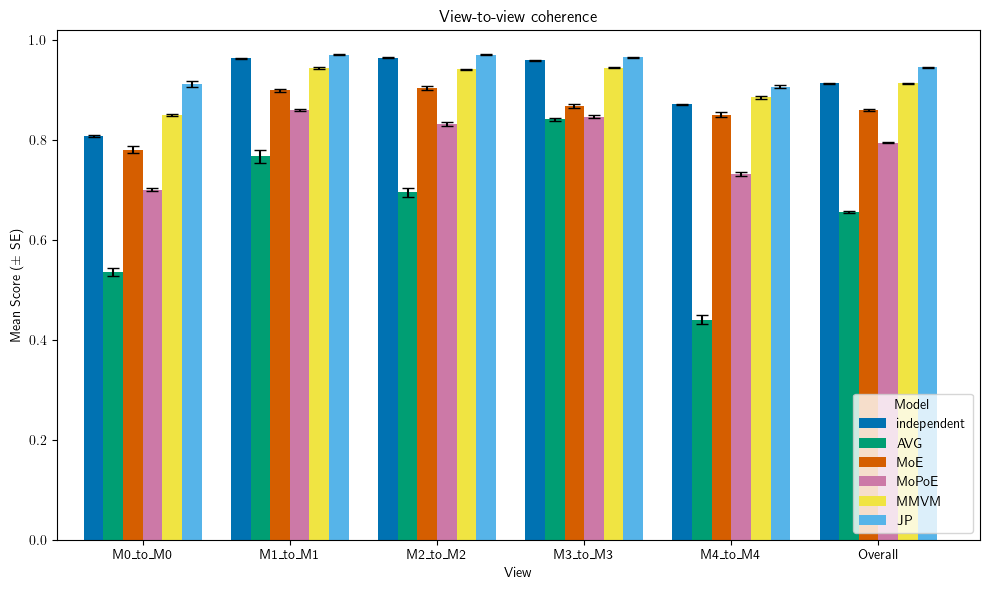

In [288]:
coherence_plots(df_subset, cols_view_to_view, "View", "View-to-view coherence", "results_figures/view_to_view_coherence_barplot.png")

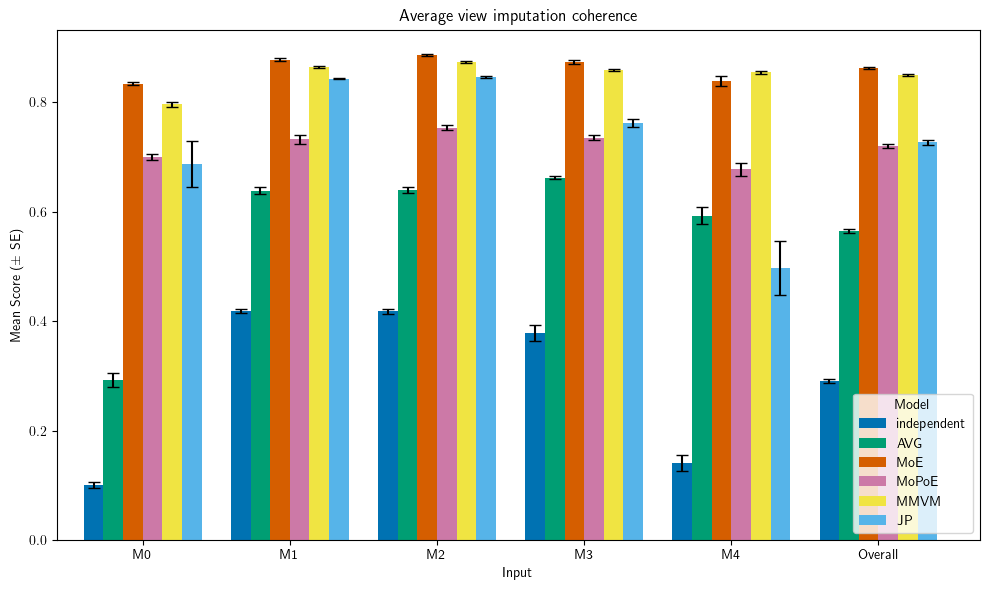

In [289]:
coherence_plots(df_subset, cols_avg, "Input", "Average view imputation coherence", "results_figures/average_imputation_coherence_barplot.png")

In [321]:
df_subset[["model.name", 'final_scores/coherence/m1_to_m0_cov']]


,model.name,final_scores/coherence/m1_to_m0_cov
7,JP,0.625300
15,JP,0.746595
24,JP,0.783053
32,independent,0.079627
33,independent,0.103365
34,independent,0.095152
35,independent,0.108874
36,independent,0.108574
37,MMVM,0.352865
38,MMVM,0.337240


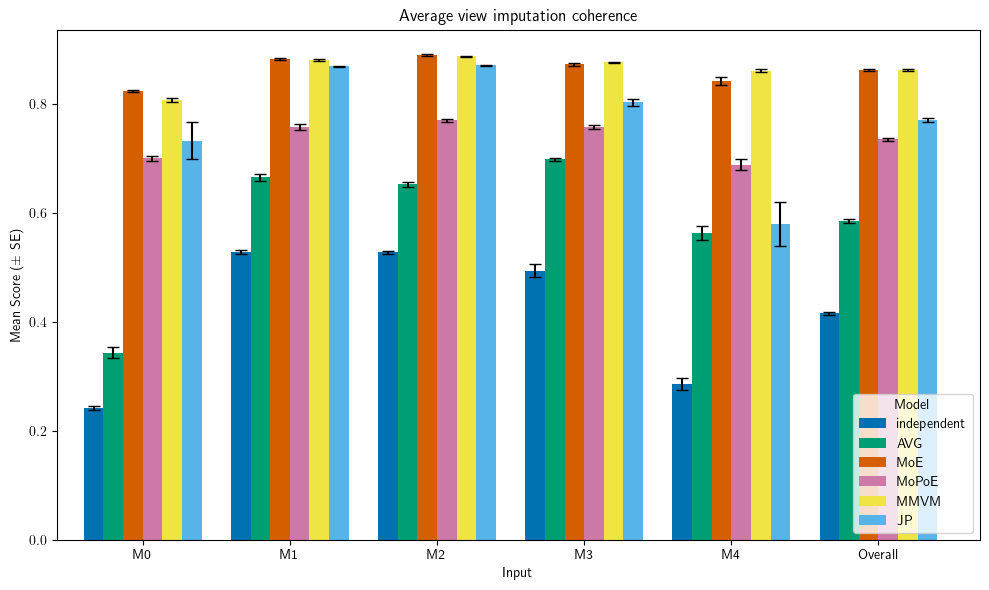

In [290]:
coherence_plots(df_subset, cols_avg_inc_views, "Input", "Average view imputation coherence", "results_figures/average_imputation_coherence_inc_views_barplot.png")

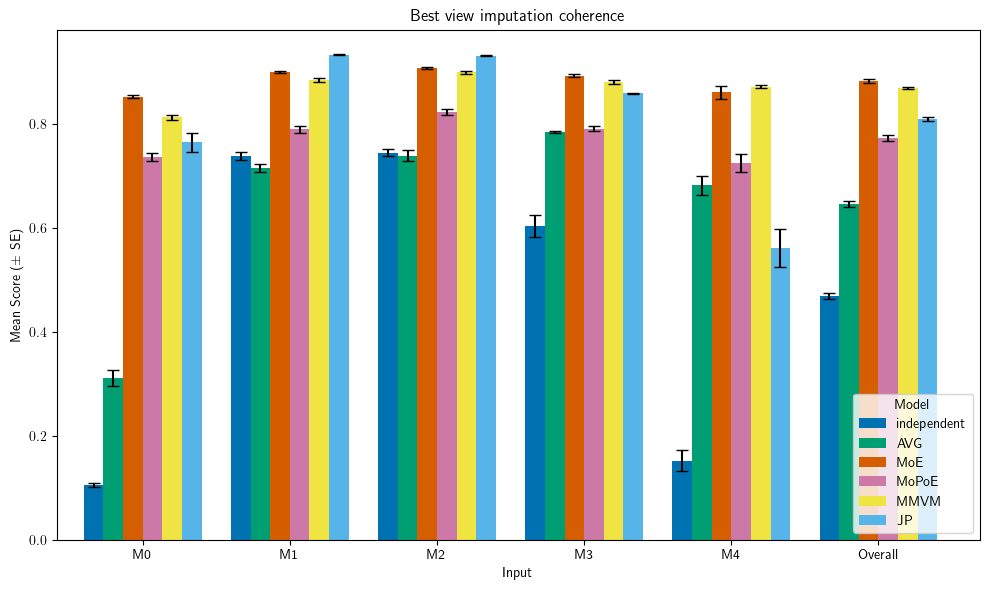

In [ ]:
coherence_plots(df_subset, cols_best, "Output", "Best view imputation coherence", "results_figures/best_imputation_coherence_barplot.png")

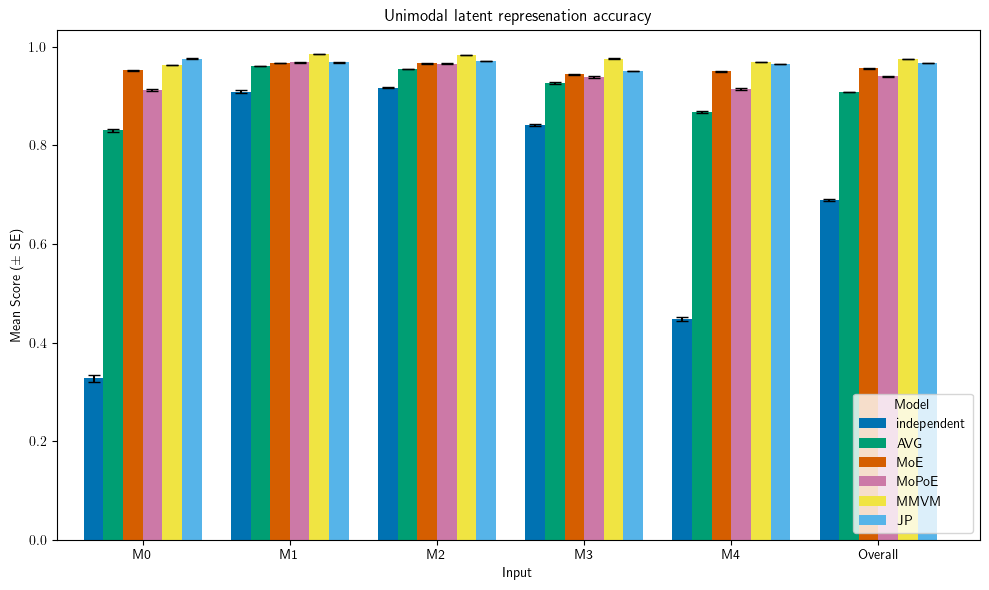

In [291]:
coherence_plots(df_subset, uni_cols, "Input", "Unimodal latent represenation accuracy", "results_figures/unimodal_barplot.png")

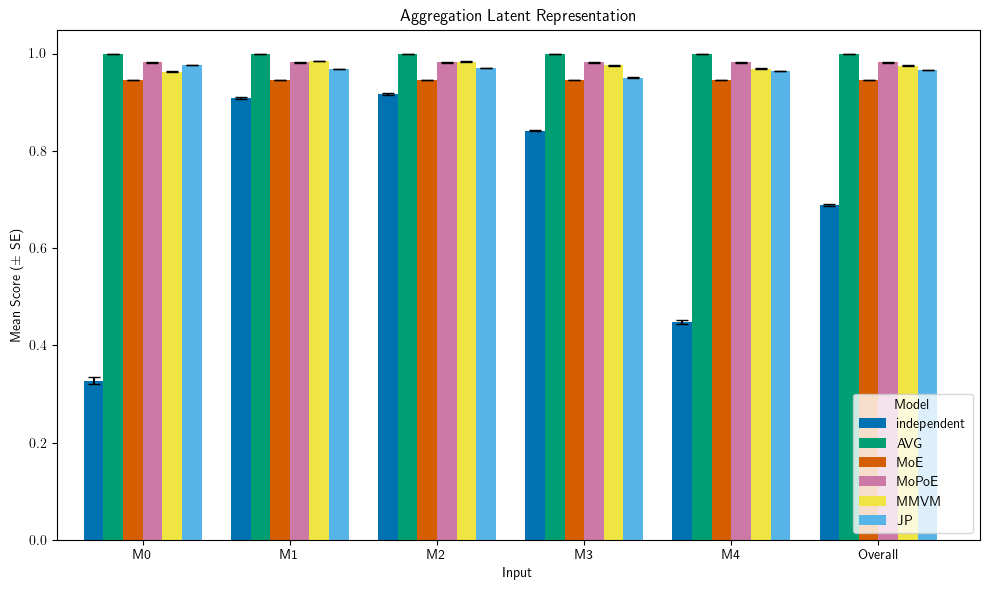

In [292]:
coherence_plots(df_subset, agg_cols, "Input", "Aggregation Latent Representation", "results_figures/agg_barplot.png")

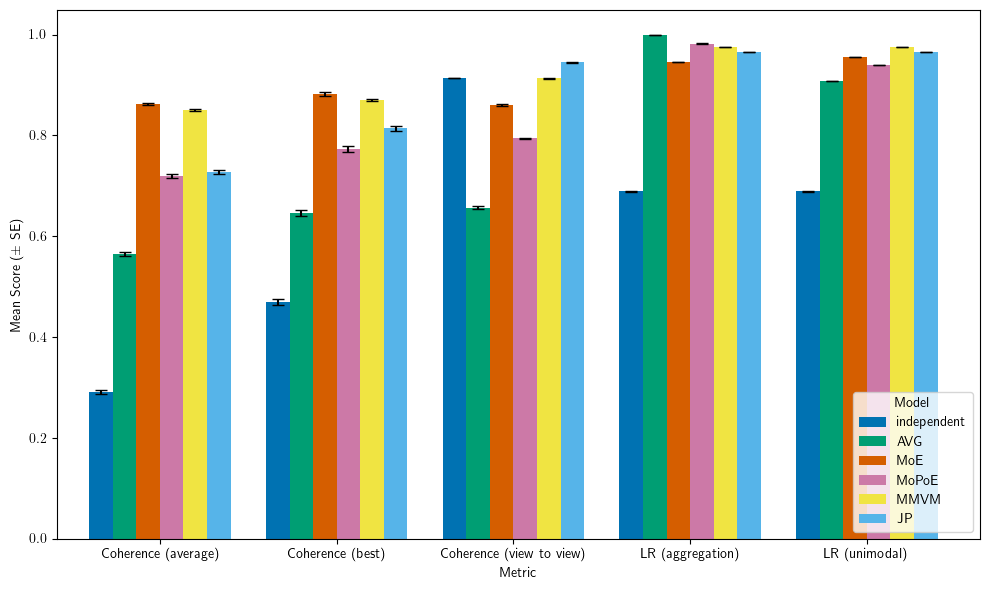

In [293]:
coherence_plots(df_subset, main_cols, "Metric", "", "results_figures/combined_results.png", combination_plot=True)

In [294]:
def two_axis_plot(df, filepath):
  _, axes = plt.subplots(2, 2, figsize=(10,8))
  axes = np.array(axes).reshape(-1)  
  y_axes = ['average_overall', 'best_overall', "agg_average", "unimodal_average"]
  y_titles =["Coherence (average)", "Coherence (best)",
             "Coherence (aggregation)", "LR (unimodal)"]
  for ax, y_axis, y_title in zip(axes, y_axes, y_titles):
    for model, group in df.groupby('model.name', observed=False):
        ax.scatter(
            group["final_scores/rec_loss"],
            group[y_axis],
            label=model,
            alpha=0.8
        )
    ax.set_xlabel("Reconstruction loss", fontsize=10)
    ax.set_ylabel(y_title, fontsize=10)
    if y_title == "LR (unimodal)":
      handles, labels = ax.get_legend_handles_labels()
      by_label = dict(zip(labels, handles))
      ax.legend(by_label.values(), by_label.keys(), title="Model", 
                loc =(0.6, 0.1), scatterpoints=1)
  
  plt.savefig(filepath)
  plt.show()

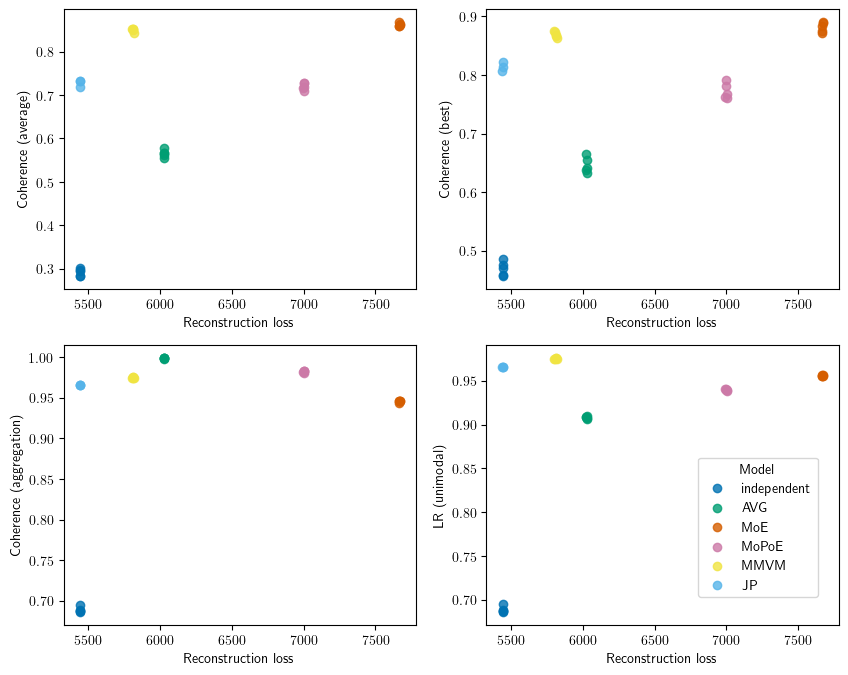

In [295]:
two_axis_plot(df_subset, "results_figures/recon_loss_plots.png")